## 🧠 Mem0: Memory Layer for AI Applications

This notebook demonstrates **Mem0**, a memory layer for AI applications that creates dynamic, personalized knowledge graphs. Mem0 enables intelligent memory management that adapts to user interactions and builds contextual understanding over time, making AI systems more personalized and context-aware.

### 🎯 What is Mem0?

Mem0 is a memory framework that transforms how AI applications store, retrieve, and utilize information. It creates dynamic knowledge graphs from user interactions, enabling AI systems to remember context, learn user preferences, and provide personalized experiences across sessions.

### 🌟 Key Features

- **🗃️ Persistent Memory** - Long-term storage of user interactions and preferences with graph-based relationships
- **🔗 Dynamic Knowledge Graphs** - Connected representation of entities, relationships, and temporal context
- **🔍 Semantic Search** - Intelligent retrieval based on meaning, context, and user-specific patterns
- **🎨 Interactive Visualization** - Real-time graph visualization and exploration capabilities
- **🤖 LLM Integration** - Smart memory extraction using modern language models like Gemini
- **👤 User Isolation** - Secure, user-specific memory spaces with personalized context
- **⏰ Temporal Awareness** - Track when information was learned, updated, or became relevant

### 🛠️ Architecture Overview

This implementation uses:
- **🤖 Google Gemini** - For LLM operations (memory extraction, semantic understanding)
- **📊 Neo4j** - As the graph database for persistent storage
- **🔧 Python** - Core framework and data processing
- **📈 NetworkX + Matplotlib** - For graph visualization and analysis

### 📋 Prerequisites

Before starting this tutorial:
- ✅ Neo4j database instance (local Docker setup provided below)
- ✅ Google API key for Gemini models
- ✅ Python environment with required dependencies
- ✅ Basic understanding of knowledge graphs and memory systems
- ✅ Familiarity with AI/LLM concepts

---


### 🐳 Neo4j Database Setup

#### 🚀 Launch Neo4j Docker Container

Set up a Neo4j instance using Docker with persistent data volumes for reliable memory storage:

```bash
docker run --name neo4j-container \
           -p 7474:7474 \
           -p 7687:7687 \
           -e NEO4J_AUTH=<your_username>/<your_password> \
           -v neo4j-data:/data \
           -v neo4j-logs:/logs \
           -d neo4j:latest 
```

#### 🔗 Connection Configuration
- **🌐 Web Interface**: http://localhost:7474 (Neo4j Browser for query testing)
- **⚡ Bolt Protocol**: bolt://localhost:7687 (Application connection)
- **👤 Username**: <your_username>
- **🔐 Password**: <your_password>

#### 📊 Verify Database Installation

After running the container:
1. Visit http://localhost:7474 in your browser
2. Login with the credentials above
3. Run a test query: `MATCH (n) OPTIONAL MATCH (n)-[r]->(m) RETURN n, r, m;` 
4. Ensure the connection is working before proceeding

#### 🎯 Why Neo4j for Memory?

Neo4j is ideal for Mem0 because:
- **🔗 Native Graph Storage** - Optimized for relationship-heavy data
- **⚡ Fast Traversals** - Efficient memory retrieval across connections  
- **📊 ACID Compliance** - Reliable data consistency for memory operations
- **🔍 Cypher Query Language** - Powerful graph querying capabilities
- **📈 Scalability** - Handles growing memory graphs efficiently

### 📦 Dependencies Installation

Install all required packages for Mem0 graph memory functionality:


In [ ]:
%pip install mem0ai mem0ai[graph] py2neo netgraph python-dotenv neo4j networkx matplotlib google-genai --upgrade


#### 📚 Package Overview

The installation includes:

- **`mem0ai`** - Core Mem0 framework for intelligent memory management
- **`mem0ai[graph]`** - Graph-specific extensions for Neo4j integration
- **`py2neo`** - Neo4j Python driver for graph database operations
- **`netgraph`** - Advanced graph visualization with interactive features
- **`python-dotenv`** - Environment variable management for secure configuration
- **`neo4j`** - Official Neo4j Python driver for direct database access
- **`networkx`** - Graph data structures and algorithms for analysis
- **`matplotlib`** - Plotting and visualization backend
- **`google-genai`** - Google Gemini API integration for LLM operations

---


### ⚙️ Environment Configuration

Load environment variables and configure secure API connections. This setup uses a `.env` file for secure credential management.

#### 🔐 Required Environment Variables

Create a `.env` file in your project directory with:

```env
NEO4J_USERNAME=<your_username>
NEO4J_PASSWORD=<your_password>
GOOGLE_API_KEY=<your_google_api_key>
```

#### 🛡️ Security Best Practices

- Never commit API keys or passwords to version control
- Use environment variables for all sensitive configuration
- Restrict database access to necessary IP ranges only
- Rotate API keys regularly for production deployments
- Consider using secret management services for production


In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["NEO4J_USERNAME"] = os.getenv("NEO4J_USERNAME")
os.environ["NEO4J_PASSWORD"] = os.getenv("NEO4J_PASSWORD")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_URL = "neo4j://localhost:7687"

print("✅ Environment variables loaded successfully.")

✅ Environment variables loaded successfully.


---

### Graph Visualization Helper Function


In [2]:
from neo4j import GraphDatabase
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import ArrowStyle
from netgraph import Graph as ngGraph


def display_graph():
    # Neo4j connection configuration
    uri = NEO4J_URL
    username = NEO4J_USERNAME
    password = NEO4J_PASSWORD

    # Connect to Neo4j
    driver = GraphDatabase.driver(uri, auth=(username, password))

    # Updated query to return node names
    query = """
    MATCH (n)
    OPTIONAL MATCH (n)-[r]->(m)
    RETURN n.name AS source_name, type(r) AS relationship_type, m.name AS target_name
    """

    # Function to execute the query and process results
    def get_graph_data(tx):
        result = tx.run(query)
        nodes = set()
        edges = []
        for record in result:
            source_name = record["source_name"]
            target_name = record["target_name"]
            relationship = record["relationship_type"]

            if source_name:
                nodes.add(source_name)
            if target_name:
                nodes.add(target_name)
                edges.append((source_name, target_name, relationship))

        return list(nodes), edges

    # Execute the query and get results
    with driver.session() as session:
        nodes, edges = session.execute_read(get_graph_data)

    # Create a NetworkX directed graph
    G = nx.DiGraph()

    # Add nodes and edges to the graph
    G.add_nodes_from(nodes)
    G.add_edges_from([(source, target, {'type': rel_type}) for source, target, rel_type in edges])

    # Set up the plot
    fig, ax = plt.subplots(figsize=(15, 12))
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # Use netgraph for layout and drawing
    try:
        plot_instance = ngGraph(G, node_layout='spring', node_size=5, node_color='lightblue',
                        edge_width=0.4, edge_alpha=1, edge_color='black',
                        node_labels=True, edge_labels=nx.get_edge_attributes(G, 'type'),
                        arrows=True, ax=ax, arrowsize=1,
                        edge_arrow_width=0.5,
                        node_label_fontdict={'size': 12})
    except:
        plt.clf()
        plt.close(fig)
        ax.clear()
        plt.close('all')
        return "Nothing to Plot, add memories"

    plt.title("Graph Data Visualization", fontsize=20)

    # Enable zoom and pan
    def zoom_factory(ax, base_scale=2.):
        def zoom_fun(event):
            cur_xlim = ax.get_xlim()
            cur_ylim = ax.get_ylim()
            xdata = event.xdata
            ydata = event.ydata
            if event.button == 'up':
                scale_factor = 1/base_scale
            elif event.button == 'down':
                scale_factor = base_scale
            else:
                scale_factor = 1
            new_width = (cur_xlim[1] - cur_xlim[0]) * scale_factor
            new_height = (cur_ylim[1] - cur_ylim[0]) * scale_factor
            relx = (cur_xlim[1] - xdata)/(cur_xlim[1] - cur_xlim[0])
            rely = (cur_ylim[1] - ydata)/(cur_ylim[1] - cur_ylim[0])
            ax.set_xlim([xdata - new_width * (1-relx), xdata + new_width * (relx)])
            ax.set_ylim([ydata - new_height * (1-rely), ydata + new_height * (rely)])
            plt.draw()
        fig = ax.get_figure()
        fig.canvas.mpl_connect('scroll_event', zoom_fun)
        return zoom_fun

    zoom = zoom_factory(ax)

    def on_press(event):
        if event.inaxes != ax: return
        ax._pan_start = (event.x, event.y)

    def on_release(event):
        if event.inaxes != ax: return
        ax._pan_start = None

    def on_motion(event):
        if event.inaxes != ax: return
        if not ax._pan_start: return
        dx = event.x - ax._pan_start[0]
        dy = event.y - ax._pan_start[1]
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        scale_x = (xlim[1] - xlim[0]) / ax.get_window_extent().width
        scale_y = (ylim[1] - ylim[0]) / ax.get_window_extent().height
        ax.set_xlim(xlim - dx * scale_x)
        ax.set_ylim(ylim + dy * scale_y)
        ax._pan_start = (event.x, event.y)
        plt.draw()

    fig.canvas.mpl_connect('button_press_event', on_press)
    fig.canvas.mpl_connect('button_release_event', on_release)
    fig.canvas.mpl_connect('motion_notify_event', on_motion)

    plt.show()

    # Close the driver connection
    driver.close()
    
print("✅ Graph visualization helper function initialized successfully.")

✅ Graph visualization helper function initialized successfully.


---

### 🧠 Mem0 Memory System Initialization

#### 🔧 Comprehensive Configuration Setup

Initialize Mem0 with all required configuration

In [3]:
from mem0 import Memory

config = {
    "llm": {
        "provider": "gemini",
        "config": {
            "model": "gemini-2.0-flash",
            "temperature": 0.5,
            "api_key": GOOGLE_API_KEY
        }
    },
    "embedder": {
        "provider": "gemini",
        "config": {
            "model": "models/gemini-embedding-001",
            "api_key": GOOGLE_API_KEY,
            "embedding_dims": 3072
        }
    },
    "graph_store": {
        "provider": "neo4j",
        "config": {
            "url": NEO4J_URL,
            "username": NEO4J_USERNAME,
            "password": NEO4J_PASSWORD
        }
    },
    "version": "v1.1"
}

memory = Memory.from_config(config_dict=config)
print("✅ Mem0 memory configuration initialized successfully.")

✅ Mem0 memory configuration initialized successfully.


In [4]:
user_id = "e3b8f1b2-9c47-4e0f-9c6e-8b4c1fa7fb72"
print("✅ User ID set successfully.")

✅ User ID set successfully.


In [5]:
memory.delete_all(user_id=user_id)

Resetting index mem0...


{'message': 'Memories deleted successfully!'}

### Add memories to mem0

In [6]:
conversation = [
    {"role": "user", "content": "Alice met Bob in Bangalore last week to discuss Project Atlas."},
    {"role": "assistant", "content": "Got it. Would you like me to track anything specific from that meeting?"}
]

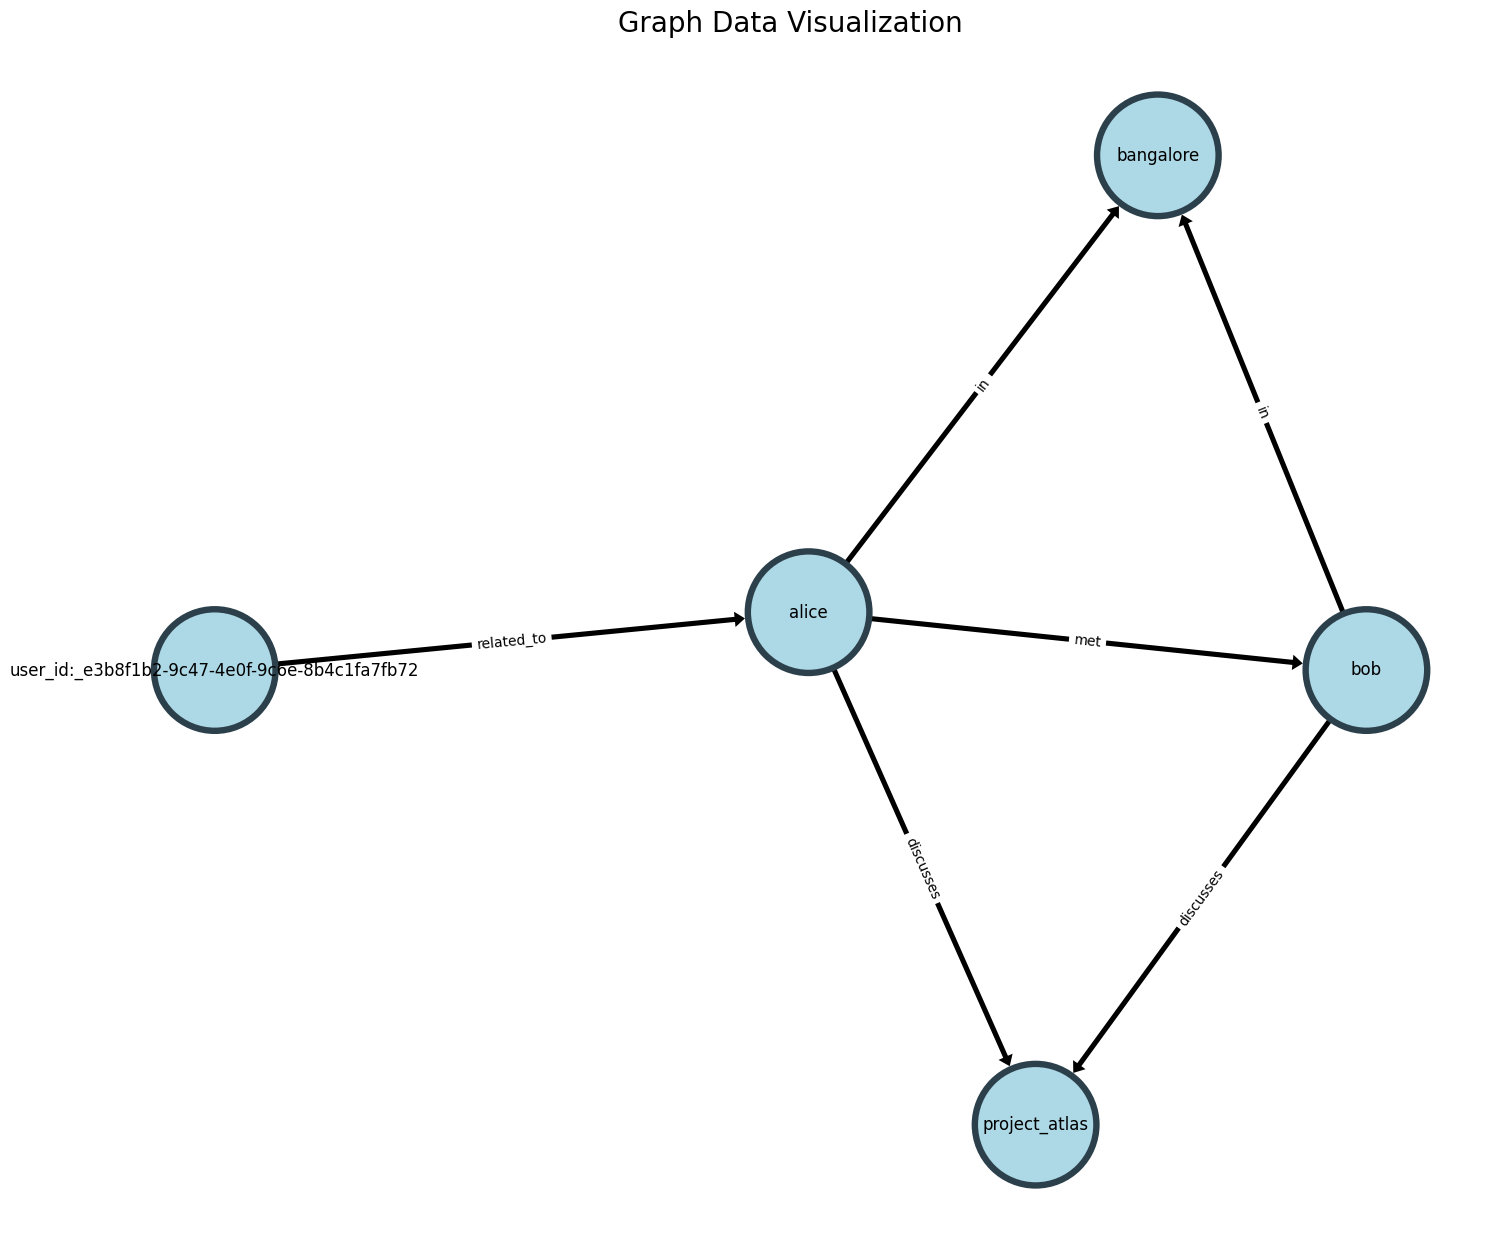

In [7]:
memory.add(messages=conversation, user_id=user_id)
display_graph()

In [8]:
conversation = [
    {"role": "user", "content": "Charlie met Alice yesterday in Mumbai, and they closed the hiring plan."},
    {"role": "assistant", "content": "Nice update. Should I mark the hiring plan as completed?"}
]

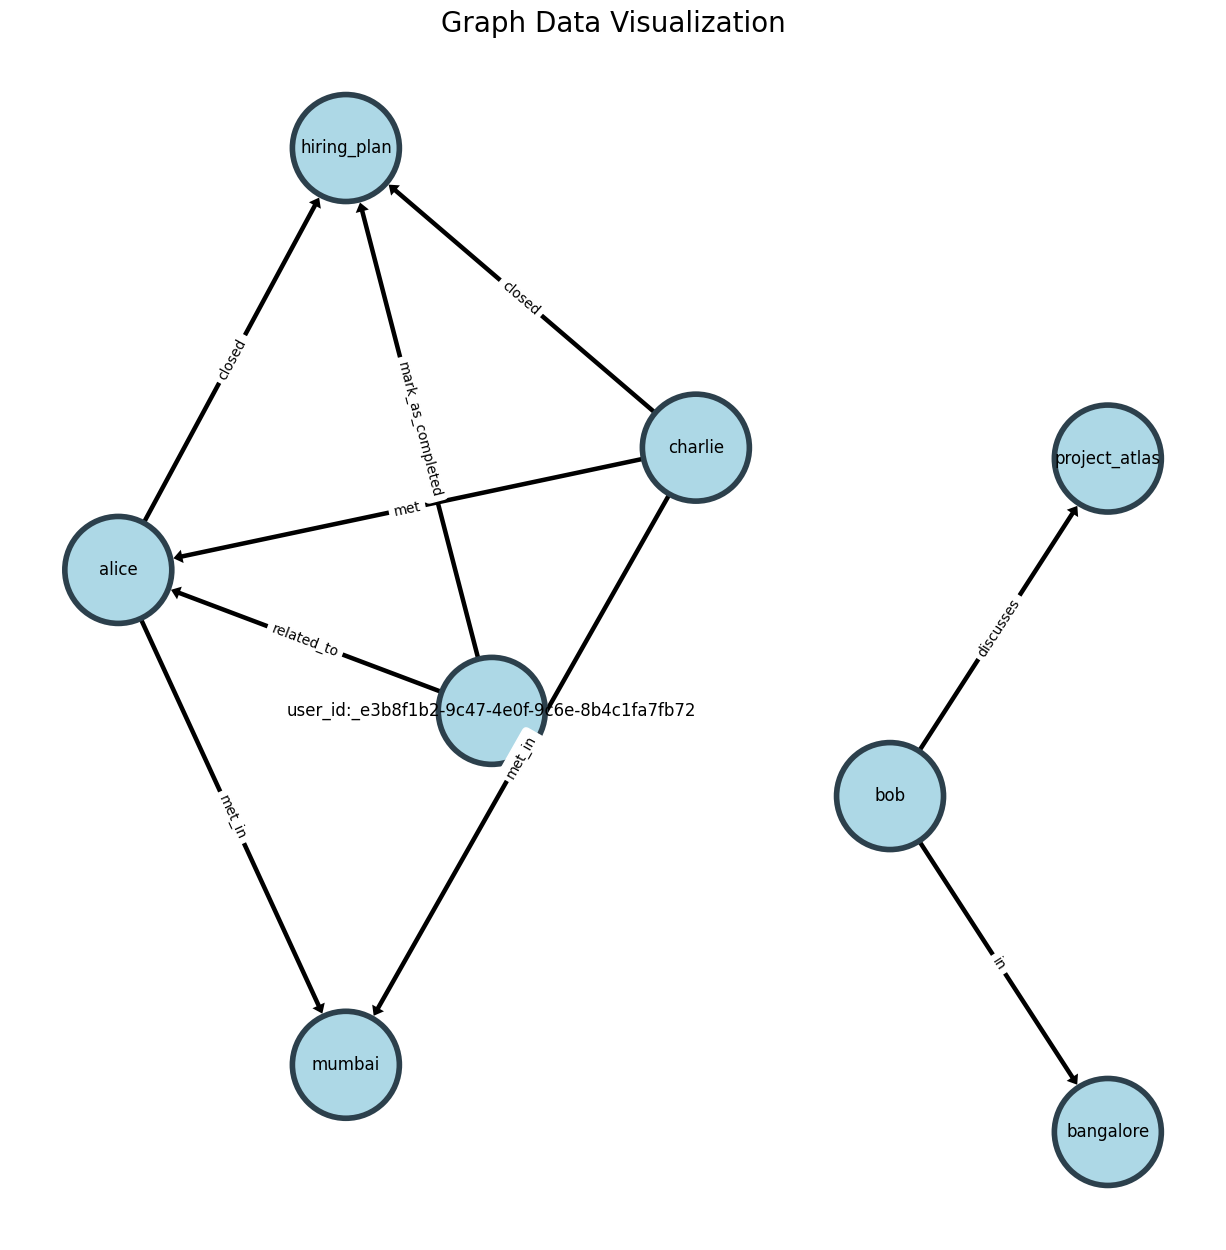

In [9]:
memory.add(messages=conversation, user_id=user_id)
display_graph()

In [10]:
conversation = [
    {"role": "user", "content": "Bob will lead Project Atlas starting next month."},
    {"role": "assistant", "content": "Understood. Do you want me to set a reminder for his transition?"}
]

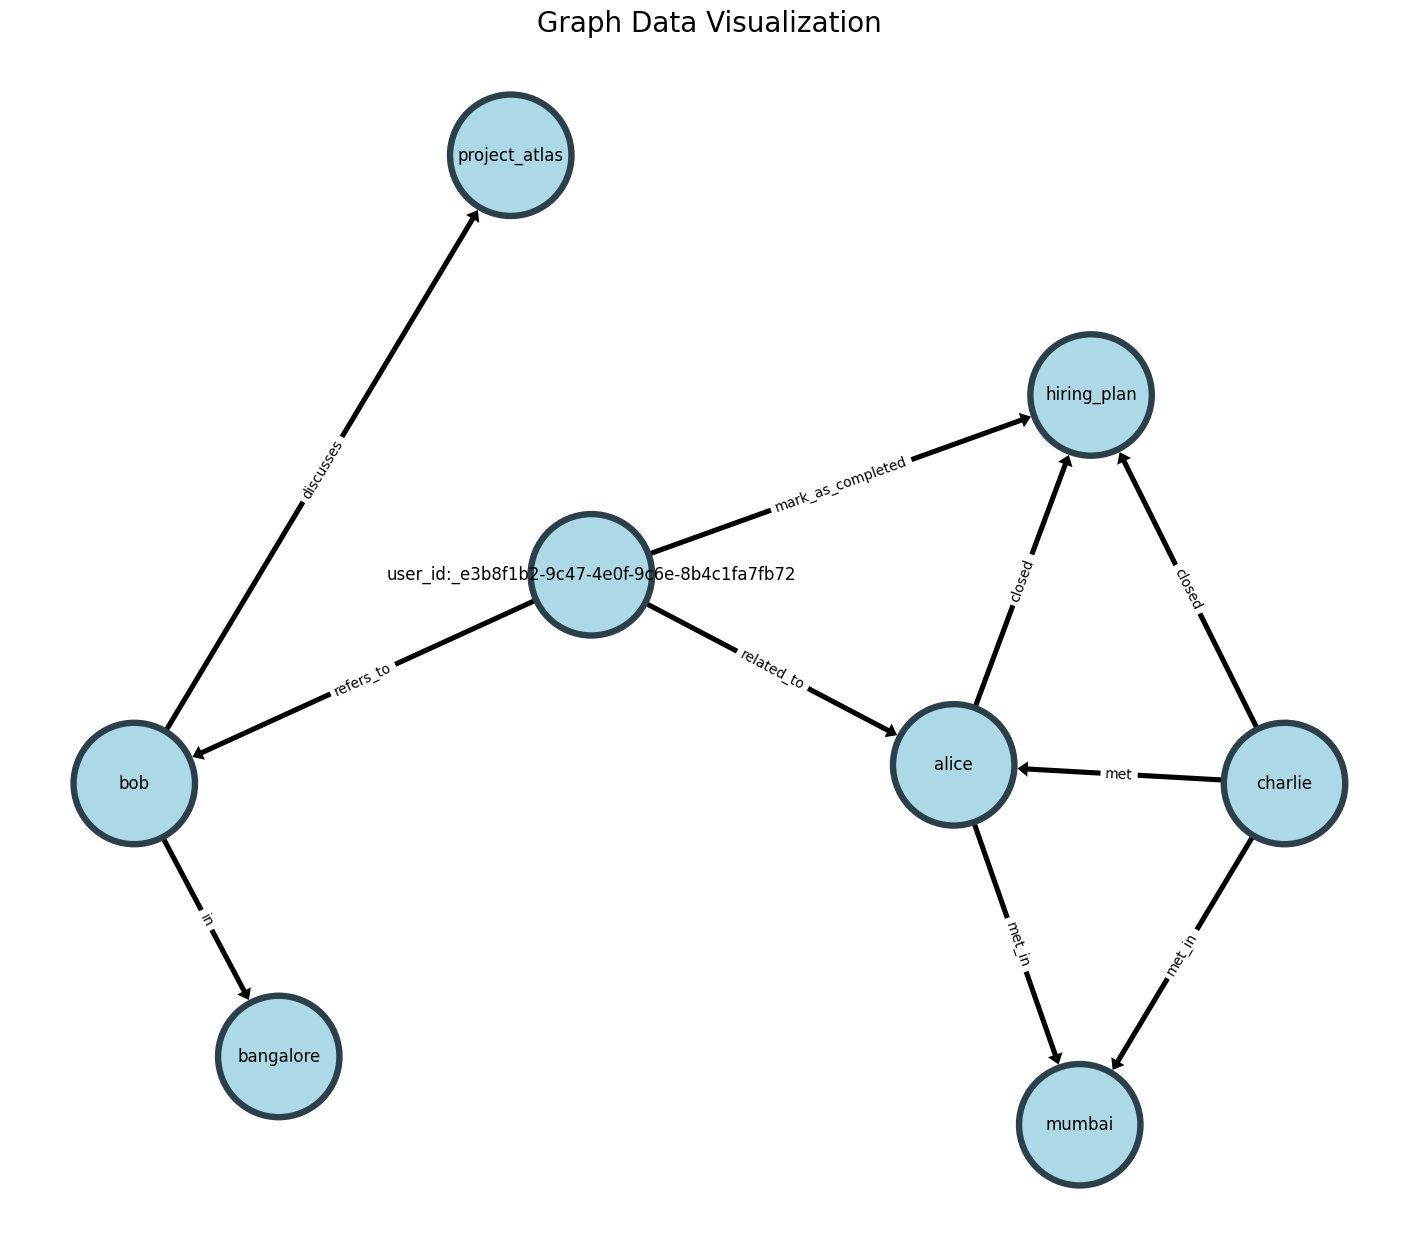

In [11]:
memory.add(messages=conversation, user_id=user_id)
display_graph()

In [12]:
conversation = [
    {"role": "user", "content": "Alice and David will meet tomorrow to review the budget."},
    {"role": "assistant", "content": "Alright. Want me to add a reminder for that meeting?"}
]

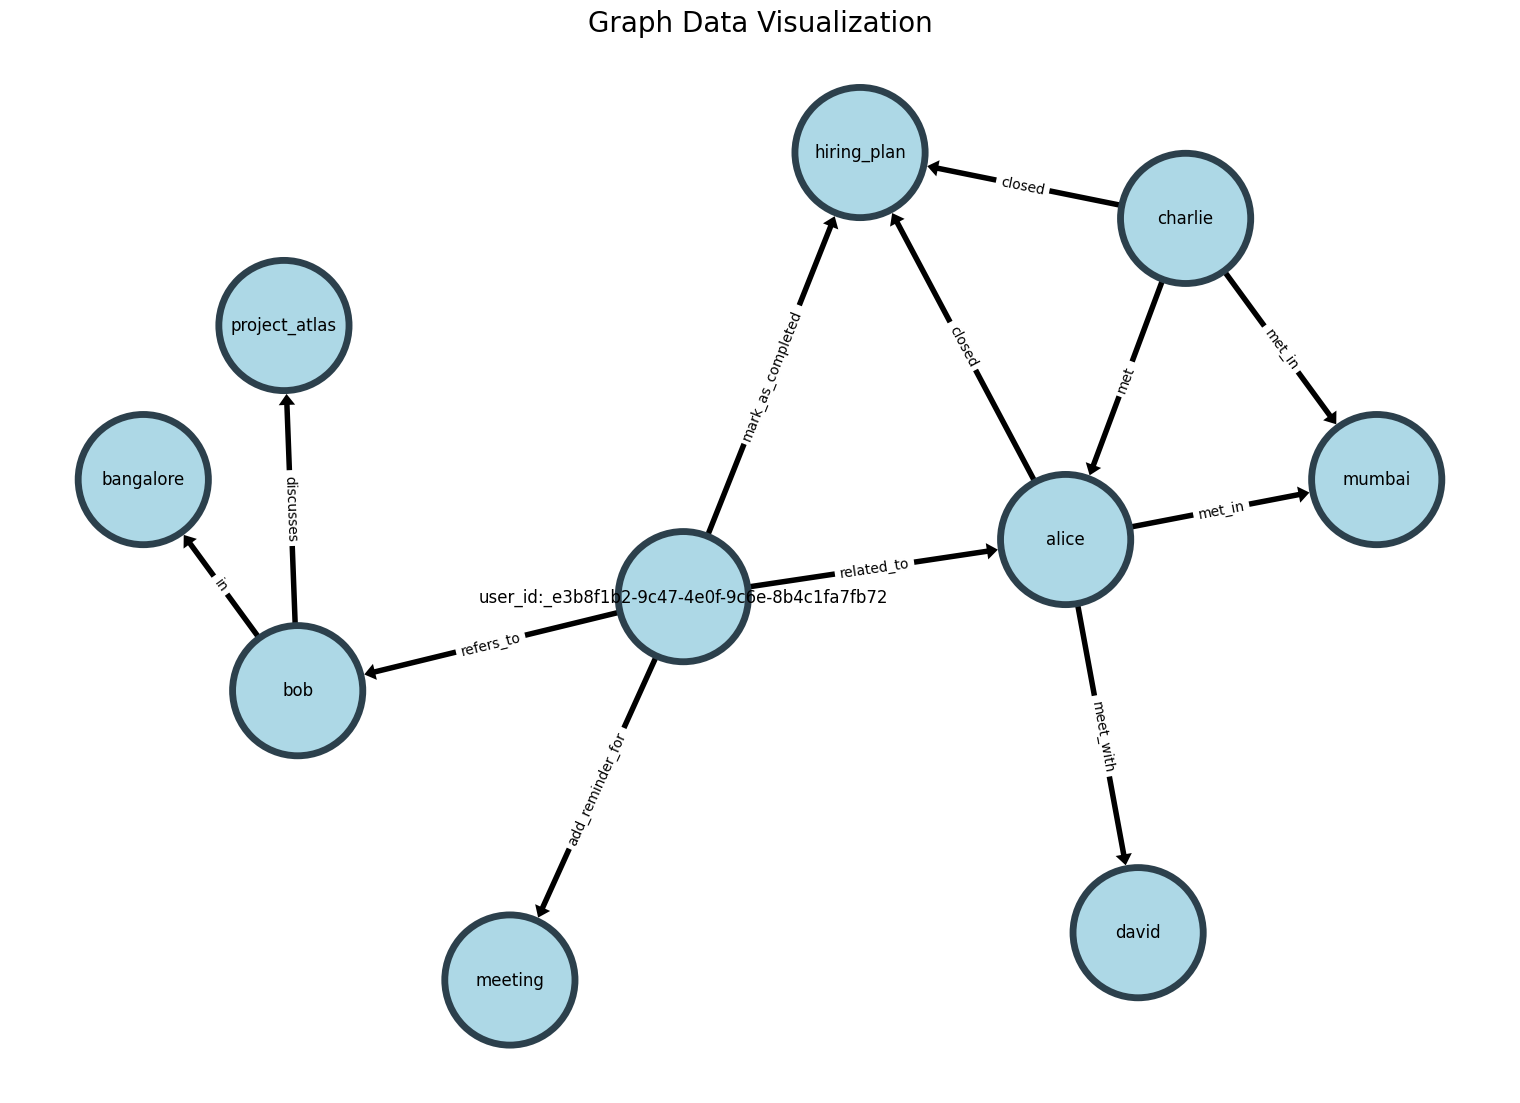

In [13]:
memory.add(messages=conversation, user_id=user_id)
display_graph()

In [14]:
conversation = [
    {"role": "user", "content": "The design team finished the prototype review call this morning."},
    {"role": "assistant", "content": "Good to know. Should I log a follow-up task for the next steps?"},
]

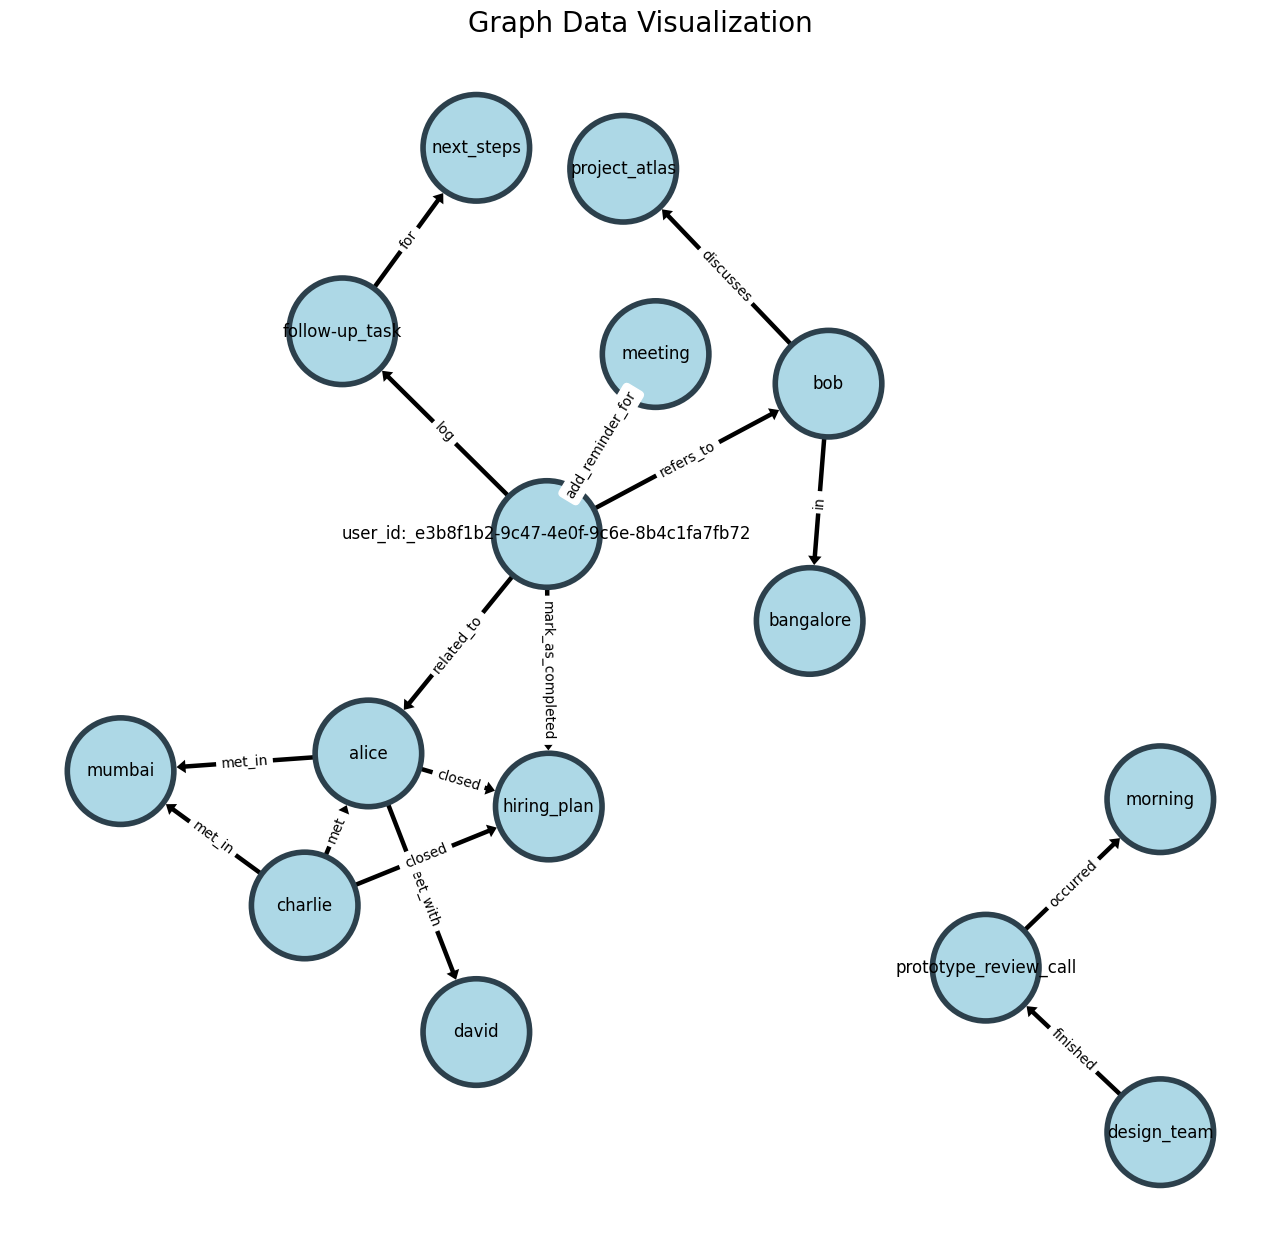

In [15]:
memory.add(messages=conversation, user_id=user_id)
display_graph()

In [16]:
conversation = [
    {"role": "user", "content": "We moved the release planning meeting to Friday."},
    {"role": "assistant", "content": "Updated. Would you like me to notify the team?"},
]

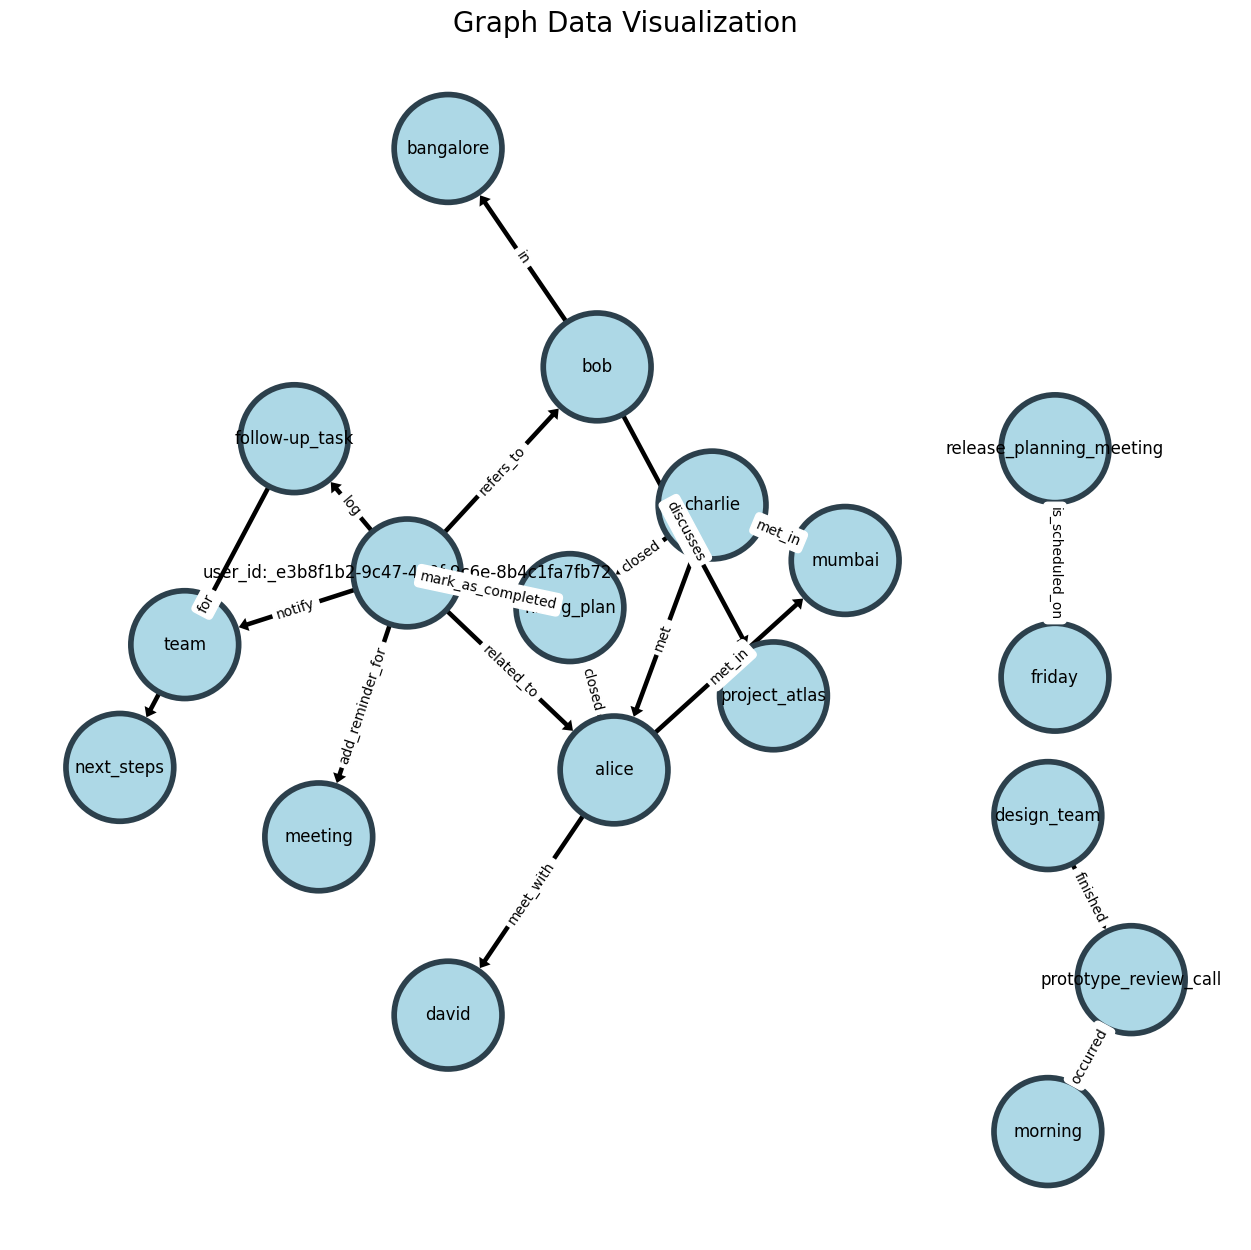

In [17]:
memory.add(messages=conversation, user_id=user_id)
display_graph()

In [18]:
conversation = [
    {"role": "user", "content": "Eve joined the operations team today."},
    {"role": "assistant", "content": "Great. Should I add her to the onboarding checklist?"}
]

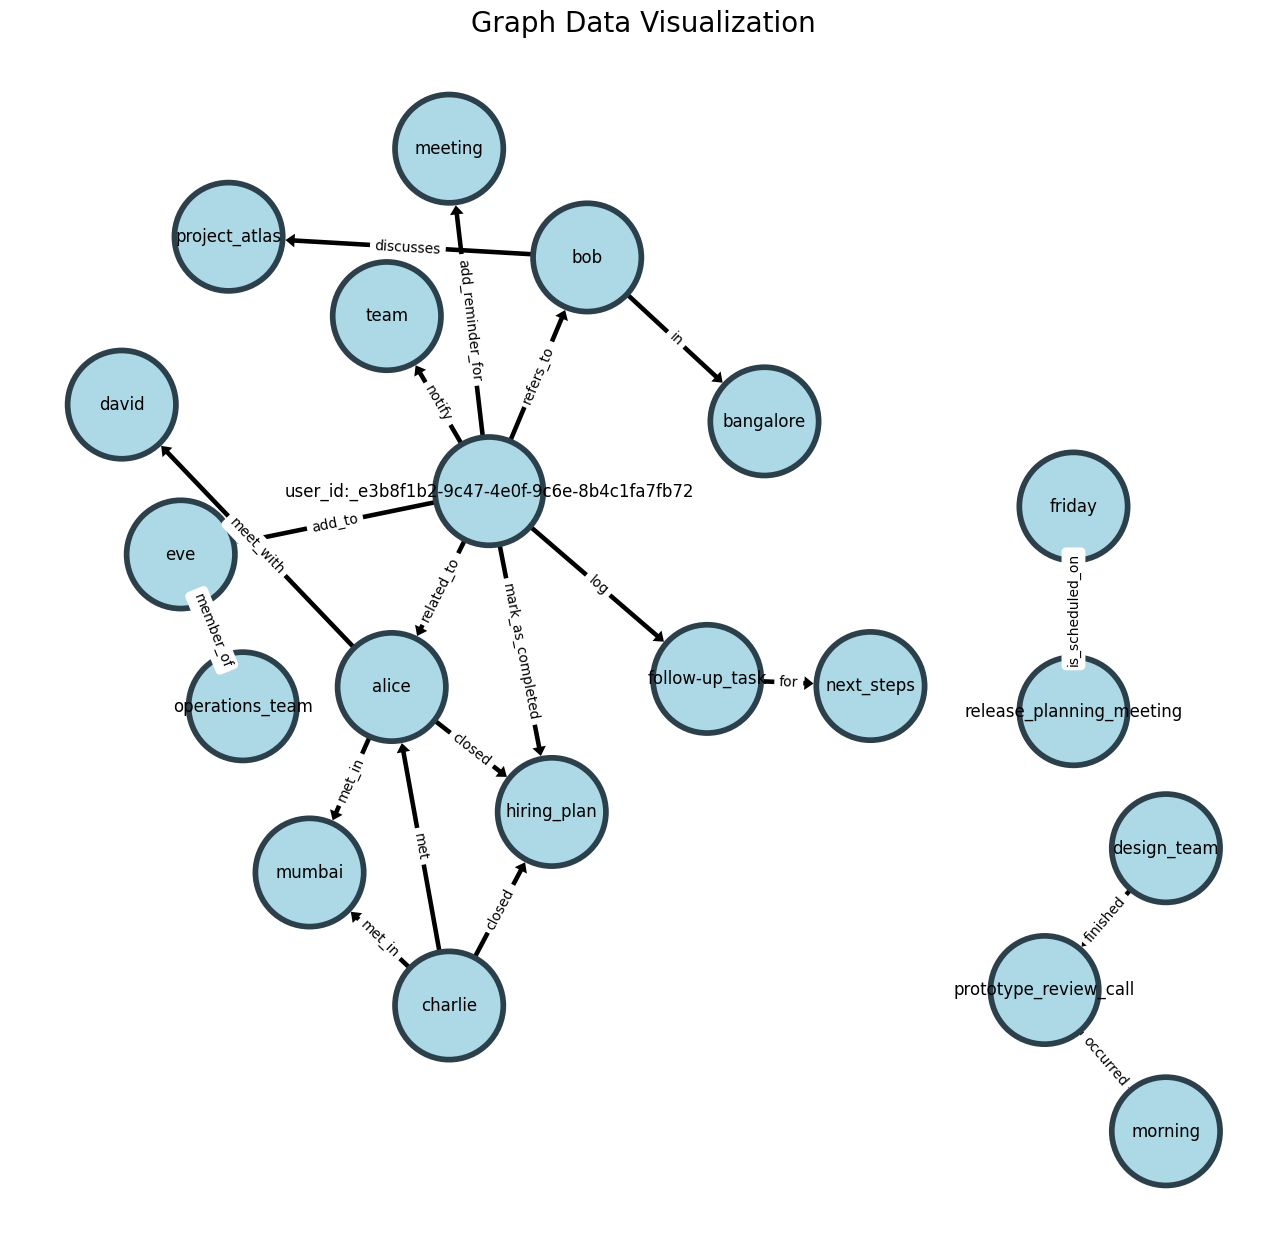

In [19]:
memory.add(messages=conversation, user_id=user_id)
display_graph()

In [20]:
conversation = [
    {"role": "user", "content": "Alice will work remotely next week."},
    {"role": "assistant", "content": "Okay. Want me to update her availability for next week?"}
]

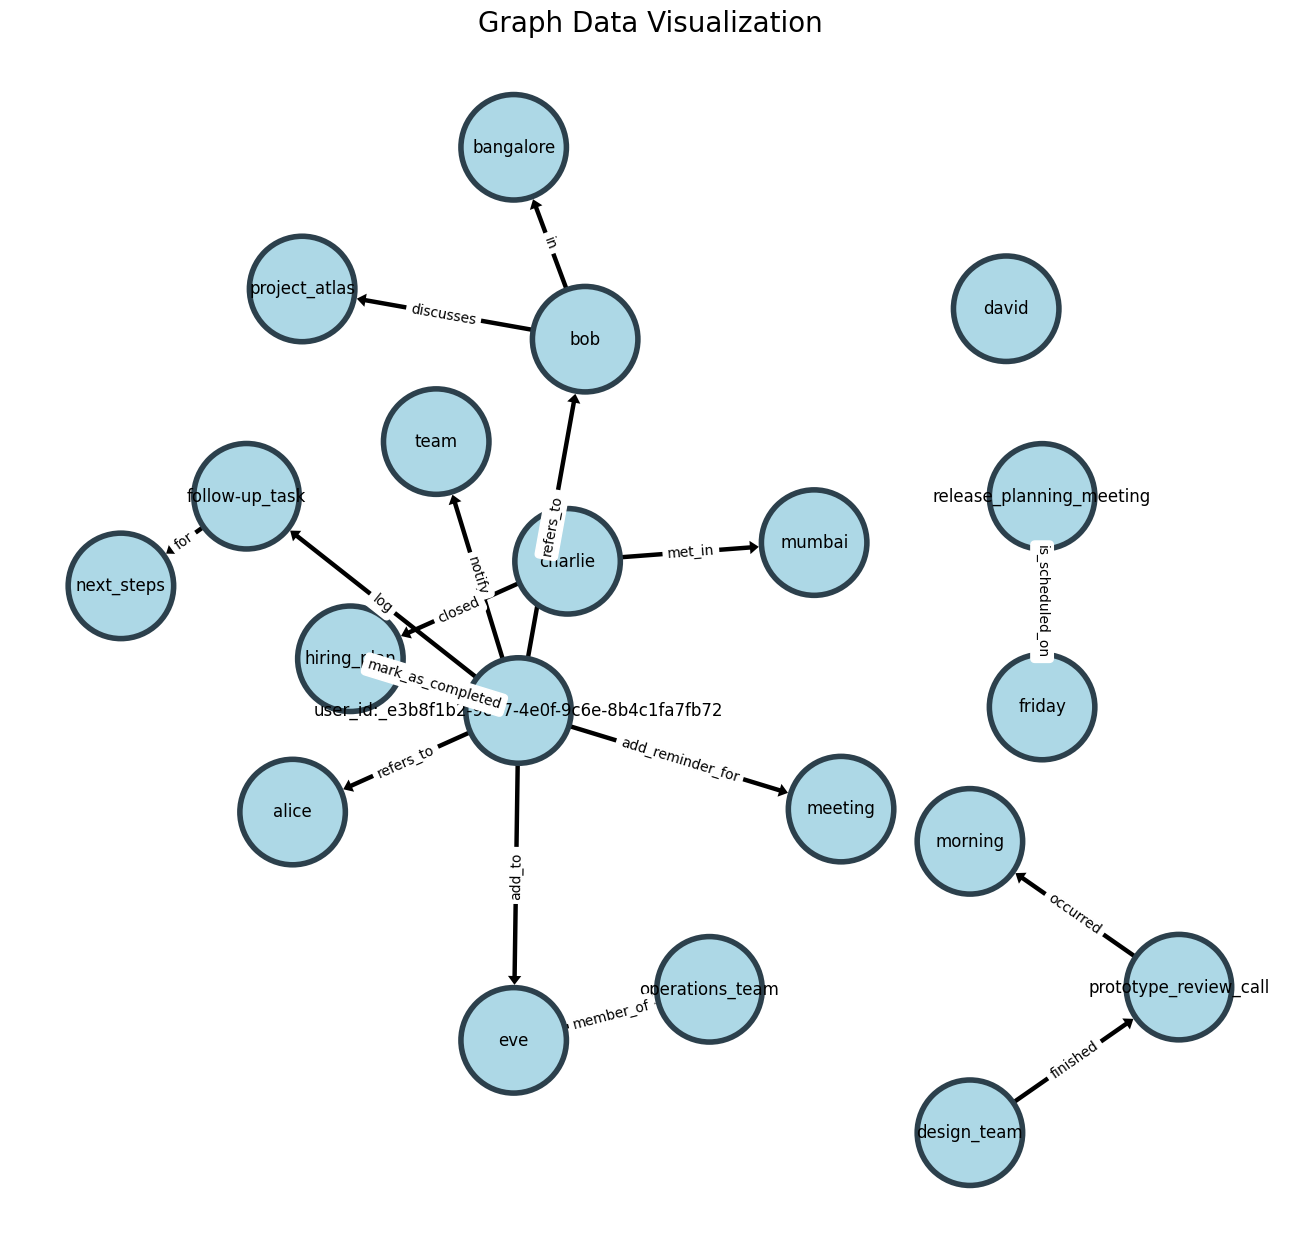

In [21]:
memory.add(messages=conversation, user_id=user_id)
display_graph()

In [22]:
conversation = [
    {"role": "user", "content": "The client demo has been postponed to next Tuesday."},
    {"role": "assistant", "content": "Thanks for the update. Should I reschedule all related tasks?"}
]

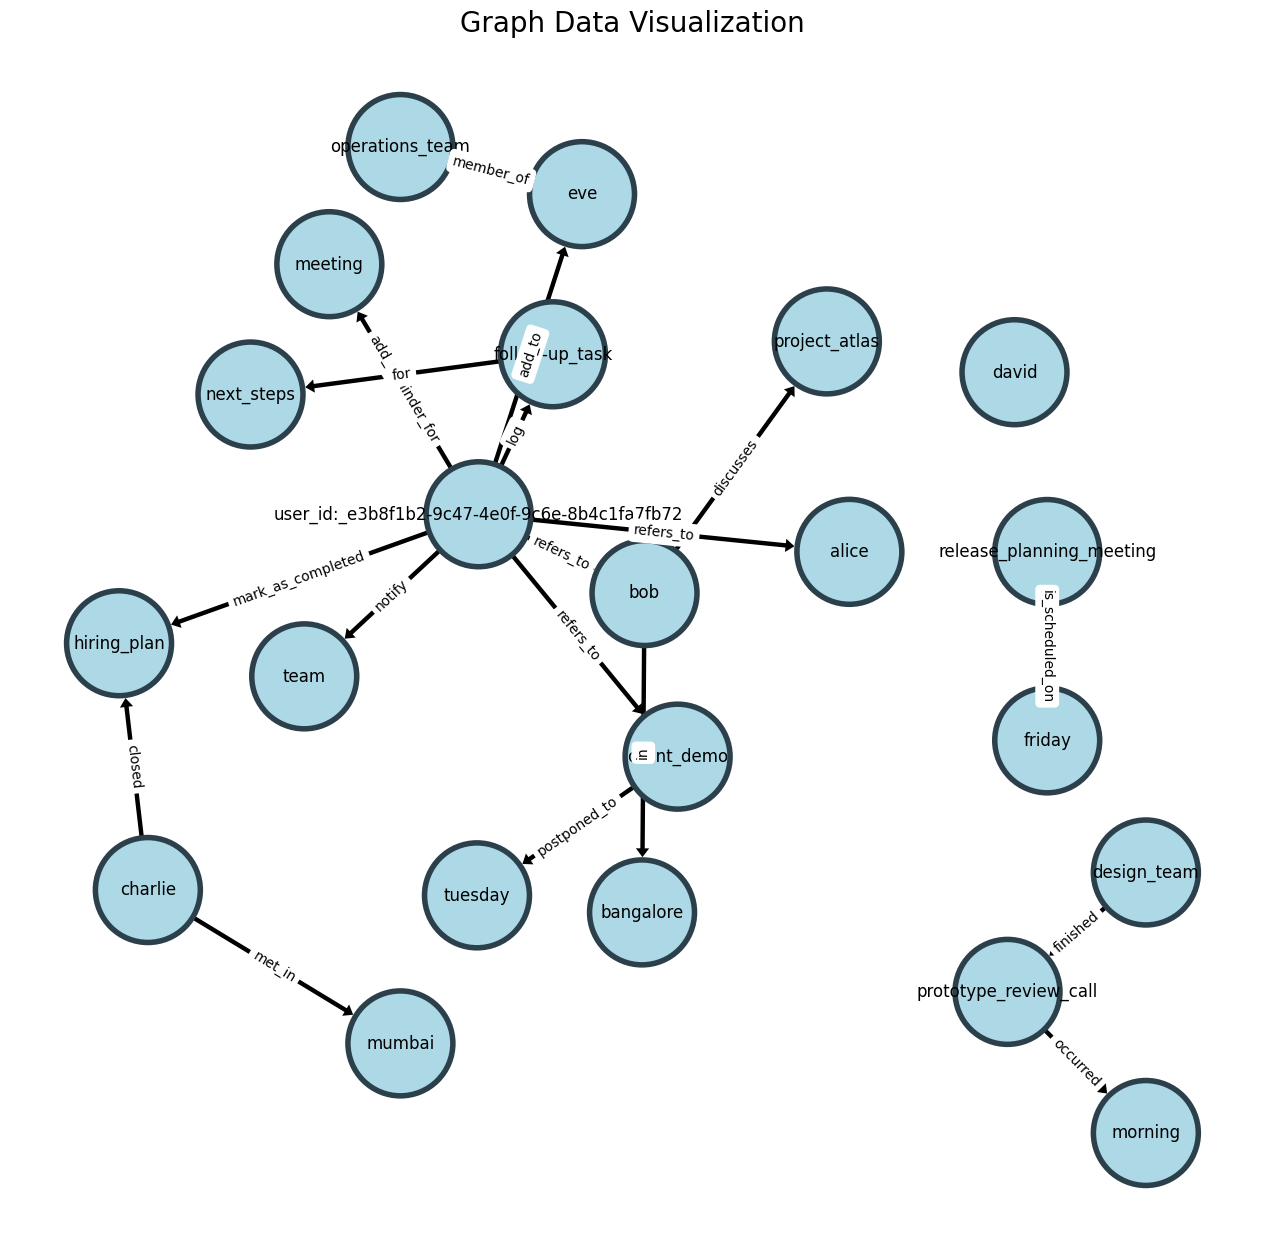

In [23]:
memory.add(messages=conversation, user_id=user_id)
display_graph()

In [24]:
conversation = [
    {"role": "user", "content": "John completed the API integration yesterday."},
    {"role": "assistant", "content": "Nice progress. Should I move the integration task to “Done”?"}
]

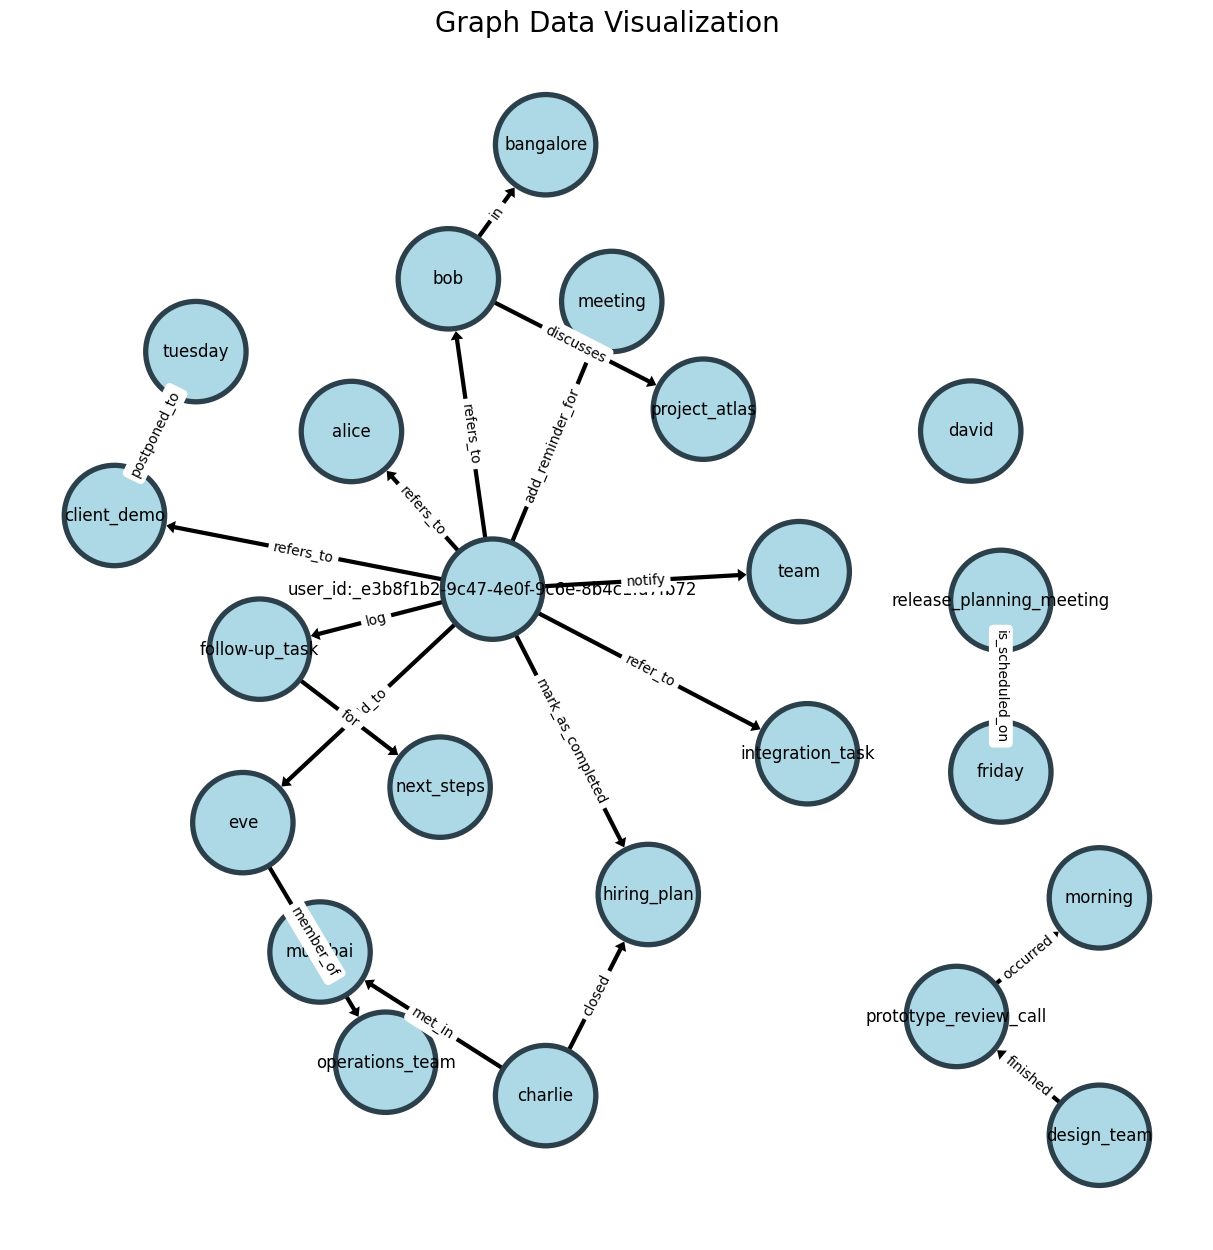

In [25]:
memory.add(messages=conversation, user_id=user_id)
display_graph()

### Retrive memories from mem0

In [26]:
memory.search(query="Where did Alice meet Bob?", user_id=user_id)

{'results': [{'id': '817b0fb7-cce1-44a3-8c77-f5157ecad5dd',
   'memory': 'Alice met Bob in Bangalore last week',
   'hash': '63d65e7499e45cd49c4868522f212aa0',
   'metadata': None,
   'score': 0.8123084866069596,
   'created_at': '2025-11-16T19:44:24.790898-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1b2-9c47-4e0f-9c6e-8b4c1fa7fb72'},
  {'id': '3af3dfee-d3b2-4fc1-b36f-1cdf750447cc',
   'memory': 'Charlie met Alice yesterday in Mumbai',
   'hash': '5df2f067fe14211866acc6fd8fc112b9',
   'metadata': None,
   'score': 0.7377068536872347,
   'created_at': '2025-11-16T19:44:58.957369-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1b2-9c47-4e0f-9c6e-8b4c1fa7fb72'},
  {'id': '98203f19-f103-4259-820a-2a807ad6ea09',
   'memory': 'Alice and David will meet tomorrow to review the budget',
   'hash': 'fa68fcb139c35f23dc849a99b8a85890',
   'metadata': None,
   'score': 0.6690293177799744,
   'created_at': '2025-11-16T19:45:53.567363-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1b2-9

In [27]:
memory.search(query="Who met in Mumbai yesterday?", user_id=user_id)

{'results': [{'id': '3af3dfee-d3b2-4fc1-b36f-1cdf750447cc',
   'memory': 'Charlie met Alice yesterday in Mumbai',
   'hash': '5df2f067fe14211866acc6fd8fc112b9',
   'metadata': None,
   'score': 0.7565485458494896,
   'created_at': '2025-11-16T19:44:58.957369-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1b2-9c47-4e0f-9c6e-8b4c1fa7fb72'},
  {'id': '817b0fb7-cce1-44a3-8c77-f5157ecad5dd',
   'memory': 'Alice met Bob in Bangalore last week',
   'hash': '63d65e7499e45cd49c4868522f212aa0',
   'metadata': None,
   'score': 0.6498898552011844,
   'created_at': '2025-11-16T19:44:24.790898-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1b2-9c47-4e0f-9c6e-8b4c1fa7fb72'},
  {'id': 'f87ab729-e120-48e7-a755-801b1abe7a4c',
   'memory': 'Design team finished the prototype review call this morning',
   'hash': 'e8d1ca336ee64cf23e79c00e591373c8',
   'metadata': None,
   'score': 0.5996707866998973,
   'created_at': '2025-11-16T19:46:06.124392-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1

In [28]:
memory.search(query="Who will lead Project Atlas?", user_id=user_id)

{'results': [{'id': '782ce163-183c-4a8a-b650-3a79a9b24ac7',
   'memory': 'Bob will lead Project Atlas starting next month',
   'hash': 'dec9873f213577cf79bb5b20ee7ce172',
   'metadata': None,
   'score': 0.8444783842229802,
   'created_at': '2025-11-16T19:45:20.145537-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1b2-9c47-4e0f-9c6e-8b4c1fa7fb72'},
  {'id': '99e84979-897e-48ad-801a-2c17aeea2092',
   'memory': 'Discussed Project Atlas',
   'hash': '37af39df727773f8856a497a42f5db53',
   'metadata': None,
   'score': 0.803761644508357,
   'created_at': '2025-11-16T19:44:24.797323-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1b2-9c47-4e0f-9c6e-8b4c1fa7fb72'},
  {'id': '8335b5b2-6444-442a-b071-79802b0cf343',
   'memory': "Integration task to be moved to 'Done'",
   'hash': 'a9aac0b430e3fbe40a1afe137ca05d86',
   'metadata': None,
   'score': 0.5710674141300099,
   'created_at': '2025-11-16T19:49:50.195890-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1b2-9c47-4e0f-9c6e-8b4c1fa

In [29]:
memory.search(query="Which team did Eve join?", user_id=user_id)

{'results': [{'id': 'c168c765-d7d6-4107-b755-96b04ac77a15',
   'memory': 'Eve joined the operations team today',
   'hash': '36a08ae6ddfab5ff3fc1d7514cc3d76d',
   'metadata': None,
   'score': 0.8008396599260353,
   'created_at': '2025-11-16T19:47:34.343763-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1b2-9c47-4e0f-9c6e-8b4c1fa7fb72'},
  {'id': '782ce163-183c-4a8a-b650-3a79a9b24ac7',
   'memory': 'Bob will lead Project Atlas starting next month',
   'hash': 'dec9873f213577cf79bb5b20ee7ce172',
   'metadata': None,
   'score': 0.5808498759892776,
   'created_at': '2025-11-16T19:45:20.145537-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1b2-9c47-4e0f-9c6e-8b4c1fa7fb72'},
  {'id': '817b0fb7-cce1-44a3-8c77-f5157ecad5dd',
   'memory': 'Alice met Bob in Bangalore last week',
   'hash': '63d65e7499e45cd49c4868522f212aa0',
   'metadata': None,
   'score': 0.5619408328265786,
   'created_at': '2025-11-16T19:44:24.790898-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1b2-9c47-4e0f-

In [30]:
memory.search(query="Who will review the budget?", user_id=user_id)

{'results': [{'id': '98203f19-f103-4259-820a-2a807ad6ea09',
   'memory': 'Alice and David will meet tomorrow to review the budget',
   'hash': 'fa68fcb139c35f23dc849a99b8a85890',
   'metadata': None,
   'score': 0.7295136235456058,
   'created_at': '2025-11-16T19:45:53.567363-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1b2-9c47-4e0f-9c6e-8b4c1fa7fb72'},
  {'id': 'f87ab729-e120-48e7-a755-801b1abe7a4c',
   'memory': 'Design team finished the prototype review call this morning',
   'hash': 'e8d1ca336ee64cf23e79c00e591373c8',
   'metadata': None,
   'score': 0.5982079388255985,
   'created_at': '2025-11-16T19:46:06.124392-08:00',
   'updated_at': None,
   'user_id': 'e3b8f1b2-9c47-4e0f-9c6e-8b4c1fa7fb72'},
  {'id': '99e84979-897e-48ad-801a-2c17aeea2092',
   'memory': 'Discussed Project Atlas',
   'hash': '37af39df727773f8856a497a42f5db53',
   'metadata': None,
   'score': 0.5845413600057374,
   'created_at': '2025-11-16T19:44:24.797323-08:00',
   'updated_at': None,
   'user_id': 'e

#### 📚 Resources

- **📖 [Mem0 Documentation](https://docs.mem0.ai/open-source/overview)** - Complete guides and API reference
- **🐙 [GitHub Repository](https://github.com/mem0ai/mem0)** - Source code and examples
